100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 2.98MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 119kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 881kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]


Epoch [1/5]  D_loss: 0.0281  G_loss: 8.1728


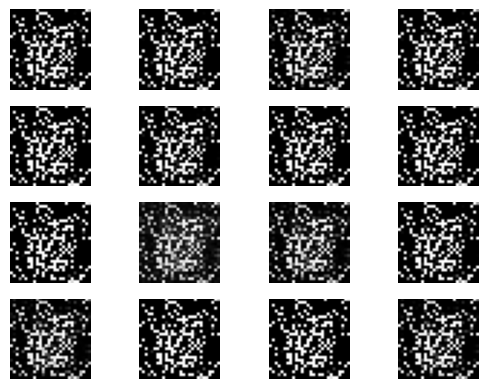

Epoch [2/5]  D_loss: 1.2098  G_loss: 2.2654


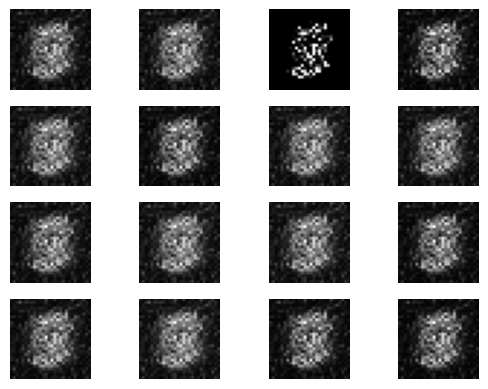

Epoch [3/5]  D_loss: 1.3339  G_loss: 1.1847


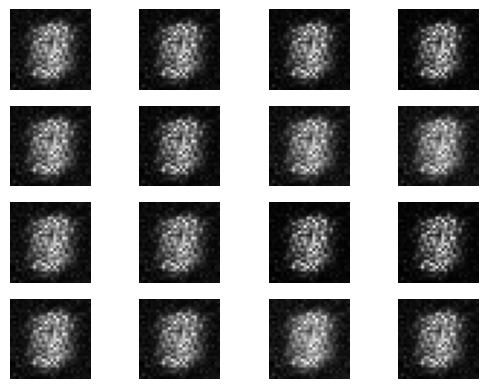

Epoch [4/5]  D_loss: 0.7640  G_loss: 0.9429


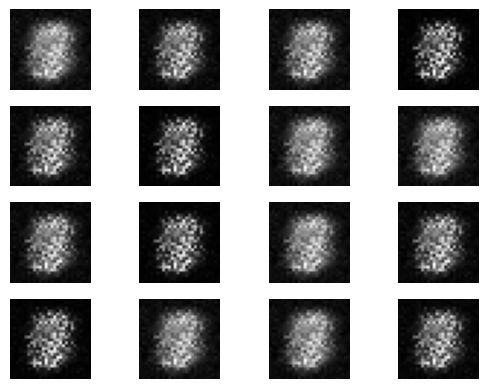

Epoch [5/5]  D_loss: 0.3169  G_loss: 2.0161


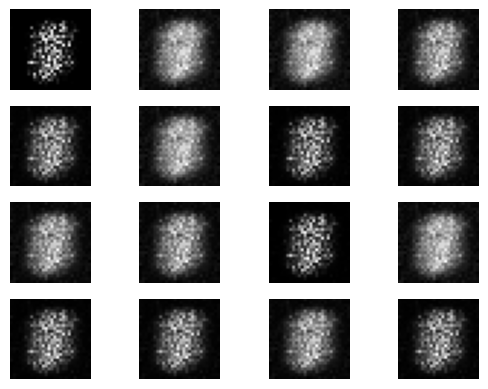

Training completed successfully!


In [1]:
# ==========================================
# GAN for MNIST Image Generation (PyTorch)
# ==========================================

# Step 1: Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Step 2: Hyperparameters
batch_size = 64
lr = 0.0002
latent_dim = 100
epochs = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 3: Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # range [-1,1]
])

dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Step 4: Define Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

# Step 5: Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(-1, 28*28)
        return self.model(img_flat)

# Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Step 6: Loss & Optimizers
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Step 7: Training Loop
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(loader):
        
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)

        real_loss = criterion(discriminator(real_imgs), real_labels)
        fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)

        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)

        g_loss = criterion(discriminator(fake_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

    # Generate sample images
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        gen_imgs = generator(z).cpu()

        fig, axs = plt.subplots(4, 4)
        count = 0
        for i in range(4):
            for j in range(4):
                axs[i,j].imshow(gen_imgs[count][0], cmap='gray')
                axs[i,j].axis('off')
                count += 1
        plt.show()

# Step 8: End
print("Training completed successfully!")